In [236]:
import pandas as pd

In [237]:
df = pd.read_csv('sleep_health_lifestyle_dataset.csv')

In [238]:
# Схлопываем две болезни в одну категорию "Болен" (Sleep_Disorder)
y_train_binary = y_train.replace({'Insomnia': 'Sleep_Disorder', 'Sleep Apnea': 'Sleep_Disorder'})
y_test_binary = y_test.replace({'Insomnia': 'Sleep_Disorder', 'Sleep Apnea': 'Sleep_Disorder'})

# Проверяем, что получилось
print("Новые классы на обучении:")
print(y_train_binary.value_counts())

Новые классы на обучении:
Sleep Disorder
None              231
Sleep_Disorder     89
Name: count, dtype: int64


In [239]:
df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),BMI Category,Blood Pressure (systolic/diastolic),Heart Rate (bpm),Daily Steps,Sleep Disorder
0,1,Male,29,Manual Labor,7.4,7.0,41,7,Obese,124/70,91,8539,NaN
1,2,Female,43,Retired,4.2,4.9,41,5,Obese,131/86,81,18754,NaN
2,3,Male,44,Retired,6.1,6.0,107,4,Underweight,122/70,81,2857,NaN
3,4,Male,29,Office Worker,8.3,10.0,20,10,Obese,124/72,55,6886,NaN
4,5,Male,67,Retired,9.1,9.5,19,4,Overweight,133/78,97,14945,Insomnia
5,6,Female,47,Student,6.1,6.9,24,4,Normal,123/60,87,9485,NaN
6,7,Male,22,Office Worker,5.1,6.1,26,6,Obese,121/70,66,15680,NaN
7,8,Male,49,Office Worker,10.7,6.2,49,8,Obese,134/87,59,18767,NaN
8,9,Male,25,Manual Labor,11.9,7.2,27,8,Underweight,112/63,99,16397,Sleep Apnea
9,10,Female,51,Retired,8.2,4.0,64,5,Overweight,125/84,76,12744,NaN


In [240]:
df.isnull().sum()

Person ID                                  0
Gender                                     0
Age                                        0
Occupation                                 0
Sleep Duration (hours)                     0
Quality of Sleep (scale: 1-10)             0
Physical Activity Level (minutes/day)      0
Stress Level (scale: 1-10)                 0
BMI Category                               0
Blood Pressure (systolic/diastolic)        0
Heart Rate (bpm)                           0
Daily Steps                                0
Sleep Disorder                           290
dtype: int64

In [241]:
df['Sleep Disorder'].unique()

array([nan, 'Insomnia', 'Sleep Apnea'], dtype=object)

In [242]:
df[['Blood systolic pressure', 'Blood diastolic pressure']] = df['Blood Pressure (systolic/diastolic)'].str.split('/', expand=True)

In [243]:
df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),BMI Category,Blood Pressure (systolic/diastolic),Heart Rate (bpm),Daily Steps,Sleep Disorder,Blood systolic pressure,Blood diastolic pressure
0,1,Male,29,Manual Labor,7.4,7.0,41,7,Obese,124/70,91,8539,NaN,124,70
1,2,Female,43,Retired,4.2,4.9,41,5,Obese,131/86,81,18754,NaN,131,86
2,3,Male,44,Retired,6.1,6.0,107,4,Underweight,122/70,81,2857,NaN,122,70
3,4,Male,29,Office Worker,8.3,10.0,20,10,Obese,124/72,55,6886,NaN,124,72
4,5,Male,67,Retired,9.1,9.5,19,4,Overweight,133/78,97,14945,Insomnia,133,78
5,6,Female,47,Student,6.1,6.9,24,4,Normal,123/60,87,9485,NaN,123,60
6,7,Male,22,Office Worker,5.1,6.1,26,6,Obese,121/70,66,15680,NaN,121,70
7,8,Male,49,Office Worker,10.7,6.2,49,8,Obese,134/87,59,18767,NaN,134,87
8,9,Male,25,Manual Labor,11.9,7.2,27,8,Underweight,112/63,99,16397,Sleep Apnea,112,63
9,10,Female,51,Retired,8.2,4.0,64,5,Overweight,125/84,76,12744,NaN,125,84


In [244]:
df ['Blood systolic pressure'] = df ['Blood systolic pressure'].astype(int)

In [245]:
df ['Blood diastolic pressure'] = df ['Blood diastolic pressure'].astype(int)

In [246]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

In [247]:
df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),BMI Category,Blood Pressure (systolic/diastolic),Heart Rate (bpm),Daily Steps,Sleep Disorder,Blood systolic pressure,Blood diastolic pressure
0,1,Male,29,Manual Labor,7.4,7.0,41,7,Obese,124/70,91,8539,None,124,70
1,2,Female,43,Retired,4.2,4.9,41,5,Obese,131/86,81,18754,None,131,86
2,3,Male,44,Retired,6.1,6.0,107,4,Underweight,122/70,81,2857,None,122,70
3,4,Male,29,Office Worker,8.3,10.0,20,10,Obese,124/72,55,6886,None,124,72
4,5,Male,67,Retired,9.1,9.5,19,4,Overweight,133/78,97,14945,Insomnia,133,78
5,6,Female,47,Student,6.1,6.9,24,4,Normal,123/60,87,9485,None,123,60
6,7,Male,22,Office Worker,5.1,6.1,26,6,Obese,121/70,66,15680,None,121,70
7,8,Male,49,Office Worker,10.7,6.2,49,8,Obese,134/87,59,18767,None,134,87
8,9,Male,25,Manual Labor,11.9,7.2,27,8,Underweight,112/63,99,16397,Sleep Apnea,112,63
9,10,Female,51,Retired,8.2,4.0,64,5,Overweight,125/84,76,12744,None,125,84


In [248]:
df = df.drop('Blood Pressure (systolic/diastolic)', axis = 1)

In [249]:
df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),BMI Category,Heart Rate (bpm),Daily Steps,Sleep Disorder,Blood systolic pressure,Blood diastolic pressure
0,1,Male,29,Manual Labor,7.4,7.0,41,7,Obese,91,8539,None,124,70
1,2,Female,43,Retired,4.2,4.9,41,5,Obese,81,18754,None,131,86
2,3,Male,44,Retired,6.1,6.0,107,4,Underweight,81,2857,None,122,70
3,4,Male,29,Office Worker,8.3,10.0,20,10,Obese,55,6886,None,124,72
4,5,Male,67,Retired,9.1,9.5,19,4,Overweight,97,14945,Insomnia,133,78
5,6,Female,47,Student,6.1,6.9,24,4,Normal,87,9485,None,123,60
6,7,Male,22,Office Worker,5.1,6.1,26,6,Obese,66,15680,None,121,70
7,8,Male,49,Office Worker,10.7,6.2,49,8,Obese,59,18767,None,134,87
8,9,Male,25,Manual Labor,11.9,7.2,27,8,Underweight,99,16397,Sleep Apnea,112,63
9,10,Female,51,Retired,8.2,4.0,64,5,Overweight,76,12744,None,125,84


In [250]:
categorical_features = ['Gender', 'Occupation', 'BMI Category']

In [251]:
df = pd.get_dummies(df, columns=categorical_features, dtype=int)

In [252]:
df.head(10)

,Person ID,Age,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),Heart Rate (bpm),Daily Steps,Sleep Disorder,Blood systolic pressure,...,Gender_Female,Gender_Male,Occupation_Manual Labor,Occupation_Office Worker,Occupation_Retired,Occupation_Student,BMI Category_Normal,BMI Category_Obese,BMI Category_Overweight,BMI Category_Underweight
0,1,29,7.4,7.0,41,7,91,8539,None,124,...,0,1,1,0,0,0,0,1,0,0
1,2,43,4.2,4.9,41,5,81,18754,None,131,...,1,0,0,0,1,0,0,1,0,0
2,3,44,6.1,6.0,107,4,81,2857,None,122,...,0,1,0,0,1,0,0,0,0,1
3,4,29,8.3,10.0,20,10,55,6886,None,124,...,0,1,0,1,0,0,0,1,0,0
4,5,67,9.1,9.5,19,4,97,14945,Insomnia,133,...,0,1,0,0,1,0,0,0,1,0
5,6,47,6.1,6.9,24,4,87,9485,None,123,...,1,0,0,0,0,1,1,0,0,0
6,7,22,5.1,6.1,26,6,66,15680,None,121,...,0,1,0,1,0,0,0,1,0,0
7,8,49,10.7,6.2,49,8,59,18767,None,134,...,0,1,0,1,0,0,0,1,0,0
8,9,25,11.9,7.2,27,8,99,16397,Sleep Apnea,112,...,0,1,1,0,0,0,0,0,0,1
9,10,51,8.2,4.0,64,5,76,12744,None,125,...,1,0,0,0,1,0,0,0,1,0


In [253]:
from sklearn.model_selection import train_test_split

In [254]:
df = df.drop(['Person ID'],axis = 1)

In [255]:
x = df.drop(['Sleep Disorder'], axis = 1)

In [256]:
y = df['Sleep Disorder']

In [257]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [258]:
from sklearn.ensemble import RandomForestClassifier

In [259]:
from sklearn.metrics import classification_report, accuracy_score

In [260]:
model = RandomForestClassifier(n_estimators = 100, random_state = 42,class_weight='balanced', max_depth = 5)

In [261]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [262]:
predictions = model.predict(X_test)

In [263]:
print(f"Общая точность (Accuracy): {accuracy_score(y_test, predictions):.2f}\n")
print("Детальный отчет (Медицинская карта алгоритма):")
print(classification_report(y_test, predictions))

Общая точность (Accuracy): 0.68

Детальный отчет (Медицинская карта алгоритма):
              precision    recall  f1-score   support

    Insomnia       0.25      0.12      0.16        17
        None       0.75      0.88      0.81        59
 Sleep Apnea       0.00      0.00      0.00         4

    accuracy                           0.68        80
   macro avg       0.33      0.33      0.32        80
weighted avg       0.61      0.68      0.63        80



In [264]:
!pip install imbalanced-learn

In [265]:
from imblearn.over_sampling import SMOTE

In [266]:
smote = SMOTE(random_state = 42)

In [267]:
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

In [268]:
print(f'Было примеров:{len(y_train)}')

Было примеров:320


In [269]:
print(f'Стало примеров:{len(y_train_smote)}')

Стало примеров:693


In [270]:
model_smote = model.fit(X_train_smote,y_train_smote)

In [271]:
predictions_smote = model_smote.predict(X_test)

In [272]:
print(f"Общая точность (Accuracy): {accuracy_score(y_test, predictions_smote):.2f}\n")
print("Детальный отчет (Медицинская карта алгоритма):")
print(classification_report(y_test, predictions_smote))

Общая точность (Accuracy): 0.66

Детальный отчет (Медицинская карта алгоритма):
              precision    recall  f1-score   support

    Insomnia       0.17      0.06      0.09        17
        None       0.74      0.88      0.81        59
 Sleep Apnea       0.00      0.00      0.00         4

    accuracy                           0.66        80
   macro avg       0.30      0.31      0.30        80
weighted avg       0.58      0.66      0.61        80



In [273]:
import matplotlib.pyplot as plt

In [274]:
feature_importances = pd.Series(model_smote.feature_importances_, index = X_train.columns)

In [275]:
plt.figure(figsize = (10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: >

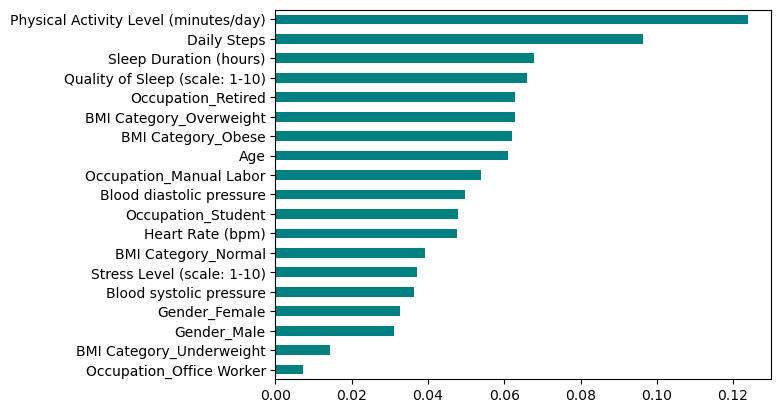

In [276]:
feature_importances.sort_values(ascending = True).plot(kind = 'barh', color = 'teal')

In [277]:
correlatin = X_train[['Physical Activity Level (minutes/day)', 'Daily Steps']].corr()

In [278]:
display(correlatin)

,Physical Activity Level (minutes/day),Daily Steps
Physical Activity Level (minutes/day),1.000000,0.043005
Daily Steps,0.043005,1.000000


In [279]:
print("Распределение уровней стресса:")
print(X_train['Stress Level (scale: 1-10)'].value_counts().sort_index())

Распределение уровней стресса:
Stress Level (scale: 1-10)
1     31
2     24
3     43
4     35
5     30
6     30
7     32
8     40
9     37
10    18
Name: count, dtype: int64


In [280]:
from sklearn.metrics import classification_report

In [281]:
columns_to_drop = [
    'Occupation_Office Worker', 
    'BMI Category_Underweight',
    'Gender_Male', 
    'Gender_Female', 
    'Blood systolic pressure', 
    'Stress Level (scale: 1-10)'
]

In [282]:
X_train_clean = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test_clean = X_test.drop(columns=columns_to_drop, errors='ignore')

In [283]:
smote_clean = SMOTE(random_state=42)

In [284]:
X_train_clean, y_train_clean = smote_clean.fit_resample(X_train_clean,y_train)

In [285]:
model_clean = RandomForestClassifier(n_estimators = 100 , random_state = 42, max_depth = 5 , class_weight = 'balanced')

In [286]:
model_clean.fit(X_train_clean,y_train_clean)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [287]:
predict_clean = model_clean.predict(X_test_clean)

In [288]:
print(classification_report(y_test, predict_clean))

              precision    recall  f1-score   support

    Insomnia       0.14      0.06      0.08        17
        None       0.74      0.85      0.79        59
 Sleep Apnea       0.00      0.00      0.00         4

    accuracy                           0.64        80
   macro avg       0.29      0.30      0.29        80
weighted avg       0.57      0.64      0.60        80



In [289]:
from sklearn.preprocessing import StandardScaler

In [290]:
scaler = StandardScaler()

In [291]:
X_train_scaled = scaler.fit_transform(X_train_clean)

In [292]:
X_test_scaled = scaler.transform(X_test_clean)

In [293]:
smote_scale = SMOTE(random_state = 42)

In [294]:
X_train_smote_scaled, y_train_smote_scaled = smote_scale.fit_resample(X_train_scaled, y_train_clean)

In [295]:
model = RandomForestClassifier(n_estimators= 100 , random_state = 42, max_depth = 7, class_weight = 'balanced')

In [296]:
model.fit(X_train_smote_scaled,y_train_smote_scaled)

,n_estimators,100
,criterion,'gini'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [297]:
predict_scaled = model.predict(X_test_scaled)

In [298]:
print(classification_report(y_test, predict_scaled))

              precision    recall  f1-score   support

    Insomnia       0.33      0.12      0.17        17
        None       0.75      0.90      0.82        59
 Sleep Apnea       0.00      0.00      0.00         4

    accuracy                           0.69        80
   macro avg       0.36      0.34      0.33        80
weighted avg       0.62      0.69      0.64        80



In [299]:
!pip install xgboost

In [300]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

In [301]:
le = LabelEncoder()

In [302]:
y_train_encoded = le.fit_transform(y_train_smote_scaled)

In [303]:
y_test_encoded = le.transform (y_test) 

In [304]:
xgb_model = XGBClassifier(
    n_estimators = 200,
    random_state = 42,
    learning_rate = 0.1,
    max_depth = 4,
    eval_metric='mlogloss'
)


In [305]:
xgb_model.fit(X_train_smote_scaled, y_train_encoded)
predictions_xgb_encoded = xgb_model.predict(X_test_scaled)

In [306]:
predictions_xgb = le.inverse_transform(predictions_xgb_encoded)
print("--- XGBOOST ---")
print(classification_report(y_test, predictions_xgb))

--- XGBOOST ---
              precision    recall  f1-score   support

    Insomnia       0.17      0.12      0.14        17
        None       0.75      0.81      0.78        59
 Sleep Apnea       0.00      0.00      0.00         4

    accuracy                           0.62        80
   macro avg       0.31      0.31      0.31        80
weighted avg       0.59      0.62      0.60        80



In [307]:

columns_to_drop = [
    'Occupation_Office Worker', 
    'BMI Category_Underweight',
    'Gender_Male', 
    'Gender_Female', 
    'Blood systolic pressure', 
    'Stress Level (scale: 1-10)'
]
X_train_clean = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test_clean = X_test.drop(columns=columns_to_drop, errors='ignore')


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)


smote = SMOTE(random_state=42)
X_train_smote_scaled, y_train_smote_binary = smote.fit_resample(X_train_scaled, y_train_binary)


le_binary = LabelEncoder()
y_train_encoded = le_binary.fit_transform(y_train_smote_binary)
y_test_encoded = le_binary.transform(y_test_binary)

xgb_binary = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.1, 
    max_depth=4, 
    random_state=42,
    eval_metric='logloss' 
)
xgb_binary.fit(X_train_smote_scaled, y_train_encoded)


predictions_encoded = xgb_binary.predict(X_test_scaled)
predictions_text = le_binary.inverse_transform(predictions_encoded)

print("--- РЕЗУЛЬТАТЫ БИНАРНОЙ КЛАССИФИКАЦИИ (ЗДОРОВ vs РАССТРОЙСТВО СНА) ---")
print(classification_report(y_test_binary, predictions_text))

--- РЕЗУЛЬТАТЫ БИНАРНОЙ КЛАССИФИКАЦИИ (ЗДОРОВ vs РАССТРОЙСТВО СНА) ---
                precision    recall  f1-score   support

          None       0.73      0.78      0.75        59
Sleep_Disorder       0.24      0.19      0.21        21

      accuracy                           0.62        80
     macro avg       0.48      0.49      0.48        80
  weighted avg       0.60      0.62      0.61        80

